# Тестовое задание "Детекция ботов"

Решение задачи бинарной классификации cookie на человеческий и
автоматизированный трафик по истории событий внутри суточного окна.

## Подход

Из событий для каждой `cookie_id` строятся агрегированные поведенческие признаки:

- общая активность и количества событий разных типов;
- интервалы между действиями;
- разнообразие объявлений, категорий, локаций и поисковых запросов;
- глубина просмотра поисковой выдачи;
- признаки из User-Agent и platform;
- наличие координат pointer.

В качестве baseline используется Random Forest на двух признаках из
`quickstart.ipynb`.

Основная модель — `CatBoostClassifier`.

Валидация производится по времени: validation расположен позже обучающей
части, что соответствует структуре train/test.

После анализа feature importance и ablation-экспериментов был сформирован
Feature Set v2, после чего параметры CatBoost подбирались с помощью Optuna.

## Ограничения

Подбор гиперпараметров проводится на основном временном validation-периоде,
поэтому полученная на нем метрика может быть несколько оптимистичной.
Качество также меняется между временными периодами, а объем обучающей
выборки в этих экспериментах различается.
Используемые признаки являются агрегатами внутри суточного окна и не
моделируют полную последовательность действий пользователя.

## Результаты

На основном временном validation-периоде:

| Модель | P@R0.7 |
| --- | ---: |
| Random Forest baseline | 0.1025 |
| CatBoost Feature Set v1 | 0.5437 |
| CatBoost Feature Set v2 | 0.5803 |
| CatBoost Feature Set v2 + Optuna | 0.5926 |

Итоговая модель обучается на всей обучающей выборке и формирует
`submission.csv`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1. Загрузка и первичный анализ данных

In [2]:
train = pd.read_csv('data/train.csv', parse_dates=['cookie_created_at', 'window_start_ts', 'window_end_ts'])
test = pd.read_csv('data/test.csv', parse_dates=['cookie_created_at', 'window_start_ts', 'window_end_ts'])
events = pd.read_csv('data/events.csv.gz', parse_dates=['event_ts'])

print(train.shape, test.shape, events.shape)
print('Доля ботов в train:', train.target.mean().round(4))
train.head()

(11091, 5) (4909, 4) (328905, 14)
Доля ботов в train: 0.0811


,cookie_id,cookie_created_at,window_start_ts,window_end_ts,target
0,ck_54a059eb7d3ea68b,2025-11-21 09:30:41,2026-04-06,2026-04-07,0
1,ck_7e4de46eeab82974,2025-09-23 10:10:24,2026-04-06,2026-04-07,0
2,ck_9320229ef6304522,2026-03-04 00:08:02,2026-04-06,2026-04-07,0
3,ck_30ccd25bc1714ed9,2026-04-05 10:52:40,2026-04-06,2026-04-07,0
4,ck_a77c5f05948cdeef,2026-01-01 03:54:35,2026-04-06,2026-04-07,0


In [3]:
events.head()

,cookie_id,event_ts,eid,event_name,platform,user_agent,item_id,item_category,item_location,seller_type,search_query,search_page,pointer_x,pointer_y
0,ck_5efbea1befdefe1b,2026-04-26 09:11:24,200,item_view,desktop,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,1027450.0,elektronika,kaliningrad,pro,NaN,NaN,NaN,NaN
1,ck_c4ca1434f3778f1d,2026-04-20 14:04:31,100,search_results_view,web,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:1...,NaN,telefony,habarovsk,NaN,iphone 13 128,4.0,NaN,NaN
2,ck_d274382b19488771,2026-04-13 12:02:56,200,item_view,WEB,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,1048743.0,kvartiry_prodazha,kirov,private,NaN,NaN,675.0,276.0
3,ck_fbbed2ff14944ce9,2026-04-08 06:12:14,100,search_results_view,web,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,NaN,bytovaya_tehnika,novosibirsk,NaN,пылесос dyson,2.0,NaN,NaN
4,ck_56cc15c7c634cb9f,2026-04-12 17:16:05,100,search_results_view,WEB,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,NaN,odezhda,sankt-peterburg,NaN,костюм мужской,2.0,NaN,NaN


In [4]:
print('TRAIN')
train.info()

print('\nTEST')
test.info()

print('\nEVENTS')
events.info()

TRAIN
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11091 entries, 0 to 11090
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   cookie_id          11091 non-null  object        
 1   cookie_created_at  11091 non-null  datetime64[ns]
 2   window_start_ts    11091 non-null  datetime64[ns]
 3   window_end_ts      11091 non-null  datetime64[ns]
 4   target             11091 non-null  int64         
dtypes: datetime64[ns](3), int64(1), object(1)
memory usage: 433.4+ KB

TEST
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4909 entries, 0 to 4908
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   cookie_id          4909 non-null   object        
 1   cookie_created_at  4909 non-null   datetime64[ns]
 2   window_start_ts    4909 non-null   datetime64[ns]
 3   window_end_ts      4909 non-null   dat

In [5]:
train['target'].value_counts()

,count
target,
0,10192
1,899


### 1.1 Первичный анализ без учета `target`

In [6]:
print(f'Количество уникальных куки в train {train['cookie_id'].nunique()}. Всего {len(train)}')
print(f'Количество уникальных куки в test {test['cookie_id'].nunique()}. Всего {len(test)}')
print(f'Пересечений train и test {len(set(train['cookie_id']) & set(test['cookie_id']))}')

Количество уникальных куки в train 11091. Всего 11091
Количество уникальных куки в test 4909. Всего 4909
Пересечений train и test 0


In [7]:
print('TRAIN')
print('window_start:', train['window_start_ts'].min(), '—', train['window_start_ts'].max())
print('window_end:  ', train['window_end_ts'].min(), '—', train['window_end_ts'].max())

print('\nTEST')
print('window_start:', test['window_start_ts'].min(), '—', test['window_start_ts'].max())
print('window_end:  ', test['window_end_ts'].min(), '—', test['window_end_ts'].max())

TRAIN
window_start: 2026-04-06 00:00:00 — 2026-04-19 00:00:00
window_end:   2026-04-07 00:00:00 — 2026-04-20 00:00:00

TEST
window_start: 2026-04-20 00:00:00 — 2026-04-26 00:00:00
window_end:   2026-04-21 00:00:00 — 2026-04-27 00:00:00


Видно, что `test` расположен позже `train` по времени. Это важно будет учитывать при выборе способа валидации модели.

In [8]:
(train['window_end_ts'] - train['window_start_ts']).value_counts()

,count
1 days,11091


Получается, все окна у нас ровно один день, так что `window_end_ts` даже и не особо нужен далее

Следующий этап — разбиение events. При этом стоит заметить, что часть строк мы теряем — те, которые не попали в соответствующие окна. Но таковы требования

#### 1.1.1 Фильтрация событий по окнам

In [9]:
def events_in_window(events, meta):
    ev = events.merge(meta[['cookie_id', 'window_start_ts', 'window_end_ts']], on='cookie_id')
    return ev.query('event_ts >= window_start_ts and event_ts < window_end_ts')

events_train = events_in_window(events, train)
events_test = events_in_window(events, test)
print(len(events_train), len(events_test))

198436 89690


In [10]:
events_train.head()

,cookie_id,event_ts,eid,event_name,platform,user_agent,item_id,item_category,item_location,seller_type,search_query,search_page,pointer_x,pointer_y,window_start_ts,window_end_ts
0,ck_d274382b19488771,2026-04-13 12:02:56,200,item_view,WEB,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,1048743.0,kvartiry_prodazha,kirov,private,NaN,NaN,675.0,276.0,2026-04-13,2026-04-14
1,ck_fbbed2ff14944ce9,2026-04-08 06:12:14,100,search_results_view,web,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,NaN,bytovaya_tehnika,novosibirsk,NaN,пылесос dyson,2.0,NaN,NaN,2026-04-08,2026-04-09
2,ck_56cc15c7c634cb9f,2026-04-12 17:16:05,100,search_results_view,WEB,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,NaN,odezhda,sankt-peterburg,NaN,костюм мужской,2.0,NaN,NaN,2026-04-12,2026-04-13
4,ck_f80d85f038cdacee,2026-04-11 16:08:12,200,item_view,desktop,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,1000845.0,bytovaya_tehnika,sankt-peterburg,private,NaN,NaN,NaN,NaN,2026-04-11,2026-04-12
5,ck_e4f046f721d10f81,2026-04-10 16:50:05,200,item_view,IOS,Mozilla/5.0 (iPhone; CPU iPhone OS 15_2 like M...,1055188.0,telefony,ekaterinburg,pro,NaN,NaN,NaN,NaN,2026-04-10,2026-04-11


#### 1.1.2 Структура событий

In [11]:
events_train['event_name'].value_counts()

,count
event_name,
item_view,74338
search_results_view,61717
photo_swipe,22951
favorite_add,12037
seller_page_view,10688
contact_phone_show,7046
login,3900
contact_chat_open,3780
contact_message_sent,1979


In [12]:
events_train['event_name'].value_counts(normalize=True).round(4)

,proportion
event_name,
item_view,0.3746
search_results_view,0.3110
photo_swipe,0.1157
favorite_add,0.0607
seller_page_view,0.0539
contact_phone_show,0.0355
login,0.0197
contact_chat_open,0.0190
contact_message_sent,0.0100


In [13]:
missing = (
    events_train.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

missing[missing > 0]

,0
search_query,68.898285
search_page,68.898285
pointer_x,66.617448
pointer_y,66.617448
seller_type,39.135036
item_id,33.067085
item_category,7.878611
item_location,4.951722


Значительная часть пропусков связана с типом события. Например, `search_query` и `search_page` заполняются только для событий поисковой выдачи. Поэтому дальше отдельно посмотрим на заполненность полей для разных `event_name`.

In [14]:
events_per_cookie = events_train.groupby('cookie_id').size()

events_per_cookie.describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
)

,0
count,11091.000000
mean,17.891624
std,17.706829
min,1.000000
1%,1.000000
5%,2.000000
25%,6.000000
50%,12.000000
75%,23.000000
95%,53.000000


Распределение количества событий заметно скошено вправо, поэтому дополнительно посмотрим на него после преобразования `log1p`.

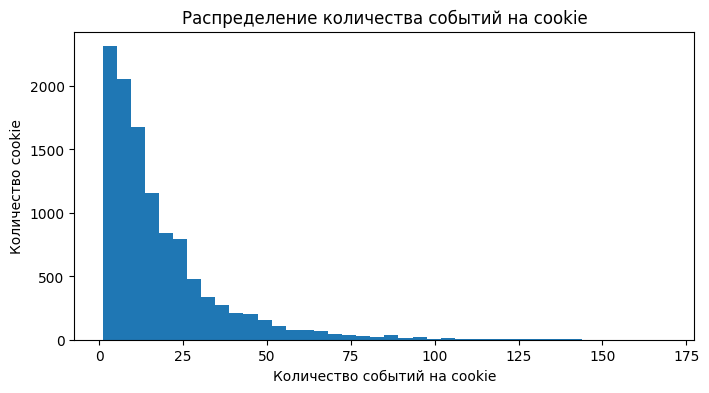

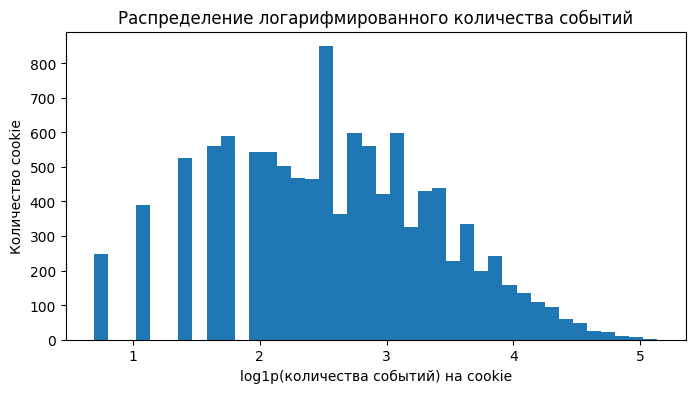

In [15]:
plt.figure(figsize=(8, 4))
plt.hist(events_per_cookie, bins=40)
plt.xlabel('Количество событий на cookie')
plt.ylabel('Количество cookie')
plt.title('Распределение количества событий на cookie')
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(np.log1p(events_per_cookie), bins=40)
plt.xlabel('log1p(количества событий) на cookie')
plt.ylabel('Количество cookie')
plt.title('Распределение логарифмированного количества событий')
plt.show()

Выглядит довольно важным посмотреть, для каких типов событий, какие поля заполняются и как часто

In [16]:
cols = [
    'item_id',
    'item_category',
    'item_location',
    'seller_type',
    'search_query',
    'search_page',
    'pointer_x',
    'pointer_y'
]

filled_by_event = (
    events_train[cols]
    .notna()
    .groupby(events_train['event_name'])
    .mean()
    .mul(100)
    .round(1)
)

filled_by_event

,item_id,item_category,item_location,seller_type,search_query,search_page,pointer_x,pointer_y
event_name,,,,,,,,
contact_chat_open,100.0,94.0,96.8,91.4,0.0,0.0,31.4,31.4
contact_message_sent,100.0,93.8,96.9,90.5,0.0,0.0,32.5,32.5
contact_phone_show,100.0,93.9,97.1,90.7,0.0,0.0,32.7,32.7
favorite_add,100.0,93.8,97.2,90.7,0.0,0.0,35.1,35.1
item_view,100.0,94.0,97.0,90.9,0.0,0.0,33.0,33.0
login,0.0,0.0,0.0,0.0,0.0,0.0,35.8,35.8
photo_swipe,100.0,94.2,96.8,91.1,0.0,0.0,34.3,34.3
search_results_view,0.0,93.9,96.9,0.0,100.0,100.0,33.2,33.2
seller_page_view,100.0,94.1,96.8,90.9,0.0,0.0,34.0,34.0


#### 1.1.3 Platform и User_agent
Стоит отметить, что обрабатывать последние столбцы (`pointer_x`, `pointer_y` обязательно нужно с привязкой к платформе).
Собственно, стоит провести анализ столбца platform

In [17]:
platform_stats = pd.DataFrame({
    'count': events_train['platform'].value_counts(dropna=False),
    'share': events_train['platform'].value_counts(
        normalize=True, dropna=False
    )
})

platform_stats

,count,share
platform,,
desktop,27855,0.140373
Web,27470,0.138433
WEB,27431,0.138236
web,27251,0.137329
ANDROID,26209,0.132078
Android,25893,0.130485
android,25889,0.130465
IOS,2634,0.013274
iOS,2626,0.013233


Видно, что некоторые категории платформ практически дублируются. При этом у похожих категорий еще и частота почти совпадает. Можно разбить все на 4 категории:
- `desktop`
- `web`
- `android`
- `ios`

Когда будем работать с тестовыми данными, нужно учесть, что могут быть различия в регистре, поэтому сделаем lower, плюс iphone вне зависимости от регистра тоже преобразуем в ios

In [18]:
print('Уникальных user_agent:', events_train['user_agent'].nunique())
print('Пропусков:', events_train['user_agent'].isna().sum())

events_train['user_agent'].value_counts().tail(20)

Уникальных user_agent: 148
Пропусков: 0


,count
user_agent,
"Mozilla/5.0 (Linux; Android 13; Redmi Note 11) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/124.0.0.0 Mobile Safari/537.36",883
"Mozilla/5.0 (Linux; Android 14; Pixel 6) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/121.0.0.0 Mobile Safari/537.36",864
"Mozilla/5.0 (Linux; Android 11; Redmi Note 11) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/124.0.0.0 Mobile Safari/537.36",851
"Mozilla/5.0 (Linux; Android 11; SM-A515F) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/118.0.0.0 Mobile Safari/537.36",843
"Mozilla/5.0 (Linux; Android 14; Redmi Note 11) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/124.0.0.0 Mobile Safari/537.36",841
curl/8.1.2,838
Avito/122.0 (Android 12; SM-A125F) okhttp/4.11.0,826
Scrapy/2.11.0 (+https://scrapy.org),804
Go-http-client/1.1,803


Если рассмотреть `head()`, ничего необычного не выявляется, однако среди наименее популярных `user_agents` фигурируют выделяющиеся *python-urllib3/2.0.7*, *python-requests/2.31.0* и так далее, которые как будто бы могут соответствовать ботам. Эта гипотеза будет рассмотрена далее при анализе `target`

#### 1.1.4 Особенности данных

In [19]:
events_train[['eid', 'event_name']].drop_duplicates().sort_values('eid')

,eid,event_name
1,100,search_results_view
0,200,item_view
8,210,photo_swipe
23,220,seller_page_view
19,300,contact_phone_show
18,301,contact_chat_open
157,303,contact_message_sent
15,400,favorite_add
29,500,login


Видно взаимно-однозначное соответствие `eid` и `event_name`. Вероятно, модели не понадобятся оба варианта.

In [20]:
print('Полных дубликатов:', events_train.duplicated().sum())

Полных дубликатов: 2952


Выявлено определенное количество дубликатов. Сразу их удалять явно не стоит, сперва необходимо проанализировать и принять решение об их дальнейшей судьбе.

In [21]:
duplicates = (
    events_train[
        events_train.duplicated(keep=False)
    ]
    .sort_values(['cookie_id', 'event_ts', 'event_name'])
)

duplicates.head(10)

,cookie_id,event_ts,eid,event_name,platform,user_agent,item_id,item_category,item_location,seller_type,search_query,search_page,pointer_x,pointer_y,window_start_ts,window_end_ts
7320,ck_0032c08d8987d0ad,2026-04-10 18:13:05,210,photo_swipe,android,Mozilla/5.0 (Linux; Android 14; SM-G991B) Appl...,1051179.0,NaN,moskva,pro,NaN,NaN,NaN,NaN,2026-04-10,2026-04-11
152927,ck_0032c08d8987d0ad,2026-04-10 18:13:05,210,photo_swipe,android,Mozilla/5.0 (Linux; Android 14; SM-G991B) Appl...,1051179.0,NaN,moskva,pro,NaN,NaN,NaN,NaN,2026-04-10,2026-04-11
18110,ck_00389b209b37394b,2026-04-14 16:26:24,200,item_view,ANDROID,Mozilla/5.0 (Linux; Android 14; SM-A515F) Appl...,1026235.0,noutbuki,novosibirsk,private,NaN,NaN,NaN,NaN,2026-04-14,2026-04-15
74538,ck_00389b209b37394b,2026-04-14 16:26:24,200,item_view,ANDROID,Mozilla/5.0 (Linux; Android 14; SM-A515F) Appl...,1026235.0,noutbuki,novosibirsk,private,NaN,NaN,NaN,NaN,2026-04-14,2026-04-15
34299,ck_005802d8a4215738,2026-04-14 14:21:17,200,item_view,Android,Avito/122.0 (Android 13; SM-A515F) okhttp/4.11.0,1011868.0,telefony,bryansk,pro,NaN,NaN,NaN,NaN,2026-04-14,2026-04-15
71605,ck_005802d8a4215738,2026-04-14 14:21:17,200,item_view,Android,Avito/122.0 (Android 13; SM-A515F) okhttp/4.11.0,1011868.0,telefony,bryansk,pro,NaN,NaN,NaN,NaN,2026-04-14,2026-04-15
31857,ck_00708a91ae901fee,2026-04-11 07:09:31,220,seller_page_view,desktop,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,1028856.0,uslugi,sankt-peterburg,private,NaN,NaN,778.0,68.0,2026-04-11,2026-04-12
177653,ck_00708a91ae901fee,2026-04-11 07:09:31,220,seller_page_view,desktop,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,1028856.0,uslugi,sankt-peterburg,private,NaN,NaN,778.0,68.0,2026-04-11,2026-04-12
66425,ck_007f95db10b6eab6,2026-04-09 14:47:54,100,search_results_view,desktop,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,NaN,avtomobili,ekaterinburg,NaN,kia rio 2019,11.0,NaN,NaN,2026-04-09,2026-04-10
148384,ck_007f95db10b6eab6,2026-04-09 14:47:54,100,search_results_view,desktop,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,NaN,avtomobili,ekaterinburg,NaN,kia rio 2019,11.0,NaN,NaN,2026-04-09,2026-04-10


In [22]:
duplicates['event_name'].value_counts()

,count
event_name,
item_view,2304
search_results_view,1822
photo_swipe,686
favorite_add,388
seller_page_view,276
contact_phone_show,170
login,104
contact_chat_open,88
contact_message_sent,66


In [23]:
duplicate_sizes = (
    events_train
    .groupby(list(events_train.columns), dropna=False)
    .size()
)

duplicate_sizes[duplicate_sizes > 1].value_counts()

,count
2,2952


Пока трудно судить о том, являются ли дубликаты ошибкой, так как время известно с точностью до секунд, а пользователь вполне мог повторить действие дважды в секунду, поэтому изучение дубликатов тоже подлежит дальнейшей проверке. Кроме того, все дубликаты идут именно парами

### 1.2 Анализ с учетом `target`
Здесь рассмотрены различные аспекты `target`, а также вышеуказанные гипотезы о влиянии некоторых признаков на это значение

#### 1.2.1 Общая активность
Начнем с количества событий на одну куки

In [24]:
train_analysis = train.copy()

train_analysis['n_events'] = (
    train_analysis['cookie_id']
    .map(events_per_cookie)
)

train_analysis['n_events'].isna().sum()

np.int64(0)

In [25]:
train_analysis.groupby('target')['n_events'].describe(
    percentiles=[0.25, 0.5, 0.75, 0.95, 0.99]
)

,count,mean,std,min,25%,50%,75%,95%,99%,max
target,,,,,,,,,,
0,10192.0,16.869015,16.173297,1.0,6.0,12.0,22.0,50.0,79.00,140.0
1,899.0,29.484983,27.515182,1.0,11.0,20.0,38.0,88.0,134.04,169.0


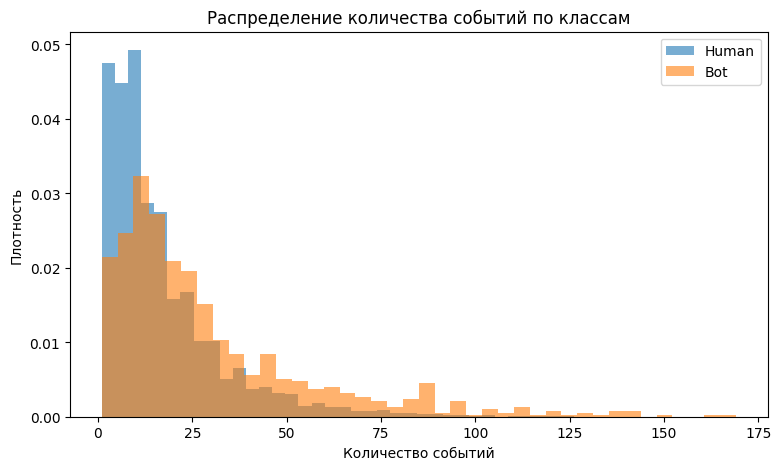

In [26]:
plt.figure(figsize=(9, 5))

plt.hist(
    train_analysis.loc[train_analysis['target'] == 0, 'n_events'],
    bins=40,
    density=True,
    alpha=0.6,
    label='Human'
)

plt.hist(
    train_analysis.loc[train_analysis['target'] == 1, 'n_events'],
    bins=40,
    density=True,
    alpha=0.6,
    label='Bot'
)

plt.xlabel('Количество событий')
plt.ylabel('Плотность')
plt.title('Распределение количества событий по классам')
plt.legend()
plt.show()

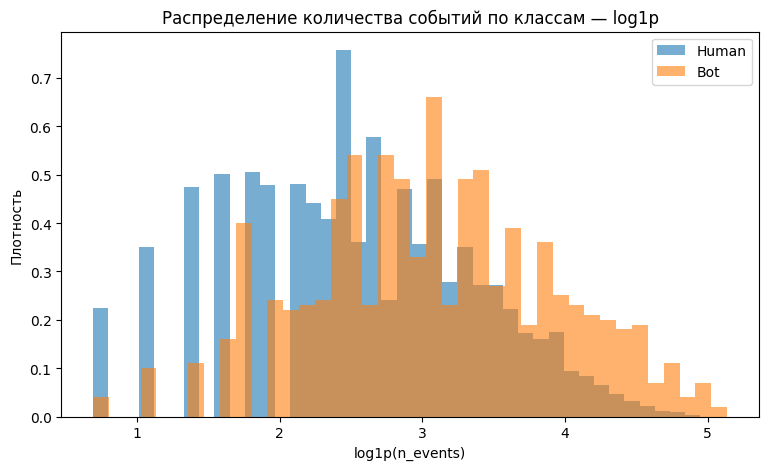

In [27]:
plt.figure(figsize=(9, 5))

plt.hist(
    np.log1p(train_analysis.loc[train_analysis['target'] == 0, 'n_events']),
    bins=40,
    density=True,
    alpha=0.6,
    label='Human'
)

plt.hist(
    np.log1p(train_analysis.loc[train_analysis['target'] == 1, 'n_events']),
    bins=40,
    density=True,
    alpha=0.6,
    label='Bot'
)

plt.xlabel('log1p(n_events)')
plt.ylabel('Плотность')
plt.title('Распределение количества событий по классам — log1p')
plt.legend()
plt.show()

Можно заметить, что в среднем боты выполняют больше операций внутри окна, но как высокие, так и низкие значения количества событий присущи как ботам, так и обычным пользователям

Теперь посмотрим на то, какие события чаще и люди и боты делают чаще

In [28]:
event_counts = (
    events_train
    .groupby(['cookie_id', 'event_name'])
    .size()
    .unstack(fill_value=0)
)

event_counts = (
    train[['cookie_id', 'target']]
    .merge(event_counts, on='cookie_id', how='left')
)

In [29]:
mean_event_counts = (
    event_counts
    .groupby('target')
    .mean(numeric_only=True)
    .T
)

mean_event_counts.columns = ['human_mean', 'bot_mean']

mean_event_counts['ratio_bot_to_human'] = (
    mean_event_counts['bot_mean'] /
    mean_event_counts['human_mean']
)

mean_event_counts.sort_values(
    'ratio_bot_to_human',
    ascending=False
)

,human_mean,bot_mean,ratio_bot_to_human
item_view,6.158752,12.867631,2.089324
search_results_view,5.141189,10.364850,2.016041
seller_page_view,0.895310,1.738598,1.941895
contact_message_sent,0.173568,0.233593,1.345833
contact_chat_open,0.333987,0.418242,1.252270
contact_phone_show,0.624117,0.761958,1.220857
photo_swipe,2.069368,2.068966,0.999805
favorite_add,1.110381,0.800890,0.721275
login,0.362343,0.230256,0.635464


Трактуется это как "в среднем на один куки бота приходится 12.86 просмотров товаров, 10.36 просмотров результатов поиска и так далее". Пока нельзя делать из этого выводы напрямую, так как у ботов в среднем и так больше событий примерно в 1.75 раз.

#### 1.2.2 Временные характеристики
Пока перейдем к анализу "длительности сессий"

In [30]:
events_train_sorted = events_train.sort_values(
    ['cookie_id', 'event_ts']
).copy()

activity_span = (
    events_train_sorted
    .groupby('cookie_id')['event_ts']
    .agg(['min', 'max'])
)

activity_span['activity_span_sec'] = (
    activity_span['max'] - activity_span['min']
).dt.total_seconds()

activity_span.head()

,min,max,activity_span_sec
cookie_id,,,
ck_000c95f1408dcb00,2026-04-19 14:49:54,2026-04-19 23:11:51,30117.0
ck_000e8c52636e3bec,2026-04-07 06:26:00,2026-04-07 08:17:21,6681.0
ck_0010e31baa4a1fb7,2026-04-15 11:53:18,2026-04-15 23:39:34,42376.0
ck_0010ec3874fb5378,2026-04-06 02:08:23,2026-04-06 17:59:27,57064.0
ck_001722063b94cae0,2026-04-10 18:07:09,2026-04-10 19:15:47,4118.0


In [31]:
# Добавляем target
activity_span = (
    train[['cookie_id', 'target']]
    .merge(
        activity_span[['activity_span_sec']],
        on='cookie_id',
        how='left'
    )
)

activity_span.groupby('target')['activity_span_sec'].describe(
    percentiles=[0.25, 0.5, 0.75, 0.95, 0.99]
)

,count,mean,std,min,25%,50%,75%,95%,99%,max
target,,,,,,,,,,
0,10192.0,11621.668662,12334.641892,0.0,1565.5,8326.5,16728.5,36544.4,55165.43,83488.0
1,899.0,12082.845384,11436.608836,0.0,3291.5,9092.0,16808.0,36042.2,48938.68,71958.0


Получили очень близкие значения, поэтому отсюда извлечь полезную информацию вряд ли получится.
Далее пробуем рассмотреть интервалы между соседними событиями. В частности статистику по медианным дельтам

In [32]:
events_train_sorted['delta_sec'] = (
    events_train_sorted
    .groupby('cookie_id')['event_ts']
    .diff()
    .dt.total_seconds()
)

time_features = (
    events_train_sorted
    .groupby('cookie_id')['delta_sec']
    .agg(
        mean_delta='mean',
        median_delta='median',
        std_delta='std',
        min_delta='min',
        max_delta='max'
    )
    .reset_index()
)

time_analysis = (
    train[['cookie_id', 'target']]
    .merge(time_features, on='cookie_id', how='left')
)

time_analysis.groupby('target')['median_delta'].describe(
    percentiles=[0.25, 0.5, 0.75, 0.95, 0.99]
)

,count,mean,std,min,25%,50%,75%,95%,99%,max
target,,,,,,,,,,
0,9949.0,219.330083,766.157260,0.0,37.0,59.0,100.00,554.1,4419.84,9005.0
1,895.0,99.973743,252.704446,0.0,14.0,25.0,52.25,533.5,973.39,3777.5


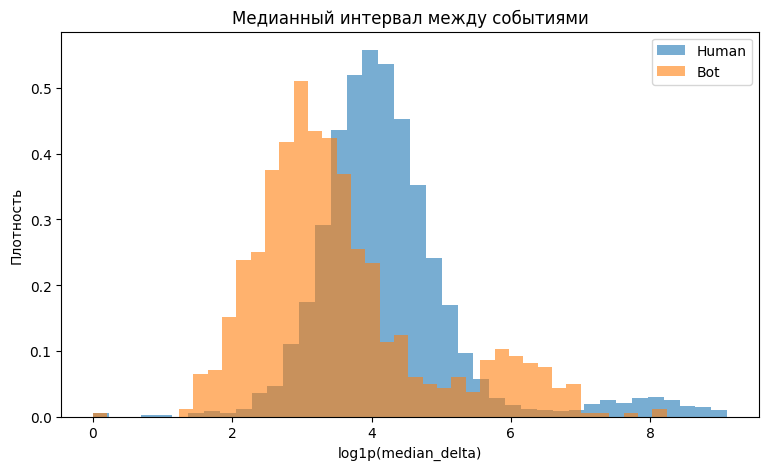

In [33]:
plt.figure(figsize=(9, 5))

for target, label in [(0, 'Human'), (1, 'Bot')]:
    values = time_analysis.loc[
        time_analysis['target'] == target,
        'median_delta'
    ].dropna()

    plt.hist(
        np.log1p(values),
        bins=40,
        density=True,
        alpha=0.6,
        label=label
    )

plt.xlabel('log1p(median_delta)')
plt.ylabel('Плотность')
plt.title('Медианный интервал между событиями')
plt.legend()
plt.show()

Здесь уже заметно, что у ботов интервалы получаются меньше, хотя и не в десятки раз

In [34]:
time_analysis['cv_delta'] = (
    time_analysis['std_delta'] /
    time_analysis['mean_delta']
)

time_analysis.groupby('target')['cv_delta'].describe(
    percentiles=[0.25, 0.5, 0.75, 0.95, 0.99]
)

,count,mean,std,min,25%,50%,75%,95%,99%,max
target,,,,,,,,,,
0,9569.0,2.035584,0.903541,0.0,1.393355,2.064049,2.622677,3.496523,4.323483,6.728216
1,885.0,2.671206,1.599097,0.0,1.502817,2.615818,3.648884,5.468481,7.245515,8.293007


Можно было предположить, что действия ботов более равномерные, но на практике видим другую картину. Все равно это можно будет использовать как дополнительный признак модели.

#### 1.2.3 User-Agent
- сначала хочется проверить уже виденные ранее "подозрительны" user_agent
- затем можно разбить user_agent на несколько признаков, так как записи часто хранят браузер, ос и другие параметры

In [35]:
events_train.query('~user_agent.str.contains("Mozilla") and ~user_agent.str.contains("Avito")')['user_agent'].unique()

array(['python-urllib3/2.0.7', 'Go-http-client/1.1',
       'Scrapy/2.11.0 (+https://scrapy.org)', 'curl/8.1.2',
       'node-fetch/3.3.2', 'python-requests/2.31.0'], dtype=object)

In [36]:
events_train_usr_a = events_train.copy()

usr_a = events_train_usr_a['user_agent'].str.lower().fillna('')


# Тип клиента
programmatic_pattern = (
    r'^(?:python-urllib3|go-http-client|scrapy|'
    r'curl|node-fetch|python-requests)/'
)

events_train_usr_a['is_programmatic_usr_a'] = usr_a.str.contains(
    programmatic_pattern,
    regex=True
)

events_train_usr_a['client_type'] = np.select(
    [
        events_train_usr_a['is_programmatic_usr_a'],
        usr_a.str.startswith('avito/'),
        usr_a.str.contains('mozilla/')
    ],
    [
        'programmatic',
        'avito_app',
        'browser'
    ],
    default='other'
)


# Семейство ОС
events_train_usr_a['os_family'] = np.select(
    [
        usr_a.str.contains(r'android'),
        usr_a.str.contains(r'iphone|ipad'),
        usr_a.str.contains(r'windows'),
        usr_a.str.contains(r'macintosh|mac os x'),
        usr_a.str.contains(r'linux')
    ],
    [
        'android',
        'ios',
        'windows',
        'macos',
        'linux'
    ],
    default='other'
)


# Семейство браузера
events_train_usr_a['browser_family'] = np.select(
    [
        usr_a.str.contains(r'edg/|edgios/|edga/'),
        usr_a.str.contains(r'firefox/|fxios/'),
        usr_a.str.contains(r'chrome/|crios/'),
        (
            usr_a.str.contains(r'safari/')
            & ~usr_a.str.contains(r'chrome/|crios/|edg/|edgios/|edga/')
        )
    ],
    [
        'edge',
        'firefox',
        'chrome',
        'safari'
    ],
    default='other'
)


# Тип устройства
events_train_usr_a['device_type'] = np.select(
    [
        usr_a.str.contains(r'ipad'),
        usr_a.str.contains(r'iphone|ipod'),
        usr_a.str.contains(r'android') & ~usr_a.str.contains(r'mobile'),
        usr_a.str.contains(r'android.*mobile'),
        (
            usr_a.str.contains(r'windows|macintosh|mac os x|linux')
            & ~usr_a.str.contains(r'android')
        )
    ],
    [
        'tablet',
        'mobile',
        'tablet',
        'mobile',
        'desktop'
    ],
    default='other'
)


def most_common(series):
    mode = series.mode()
    return mode.iloc[0] if not mode.empty else 'other'


usr_a_features = (
    events_train_usr_a
    .groupby('cookie_id')
    .agg(
        main_client_type=('client_type', most_common),
        main_browser_family=('browser_family', most_common),
        main_os_family=('os_family', most_common),
        main_device_type=('device_type', most_common),

        has_programmatic_usr_a=('is_programmatic_usr_a', 'max'),
        programmatic_events=('is_programmatic_usr_a', 'sum')
    )
    .reset_index()
)


usr_a_analysis = (
    train[['cookie_id', 'target']]
    .merge(
        usr_a_features,
        on='cookie_id',
        how='left'
    )
)

usr_a_analysis.head()

,cookie_id,target,main_client_type,main_browser_family,main_os_family,main_device_type,has_programmatic_usr_a,programmatic_events
0,ck_54a059eb7d3ea68b,0,avito_app,other,android,tablet,False,0
1,ck_7e4de46eeab82974,0,browser,chrome,windows,desktop,False,0
2,ck_9320229ef6304522,0,browser,chrome,windows,desktop,False,0
3,ck_30ccd25bc1714ed9,0,browser,chrome,windows,desktop,False,0
4,ck_a77c5f05948cdeef,0,browser,chrome,macos,desktop,False,0


In [37]:
for col in [
    'main_client_type',
    'main_browser_family',
    'main_os_family',
    'main_device_type'
]:
    display(
        pd.crosstab(
            usr_a_analysis[col],
            usr_a_analysis['target'],
            normalize='columns'
        ).rename(columns={0: 'human', 1: 'bot'})
    )

target,human,bot
main_client_type,,
avito_app,0.190738,0.219132
browser,0.793956,0.731924
programmatic,0.015306,0.048943


target,human,bot
main_browser_family,,
chrome,0.652963,0.588432
firefox,0.123038,0.133482
other,0.206044,0.268076
safari,0.017955,0.010011


target,human,bot
main_os_family,,
android,0.422881,0.317019
ios,0.054258,0.028921
linux,0.020703,0.083426
macos,0.121272,0.122358
other,0.015306,0.048943
windows,0.365581,0.399333


target,human,bot
main_device_type,,
desktop,0.507555,0.605117
mobile,0.322704,0.145717
other,0.015306,0.048943
tablet,0.154435,0.200222


Программные клиенты действительно чаще встречаются у ботов: примерно 4.9% против 1.5% у обычных пользователей. Также видны различия по ОС и типу устройства, поэтому эти характеристики имеет смысл сохранить как отдельные категориальные признаки.

In [38]:
events_train_usr_a['is_programmatic_usr_a'].value_counts()

,count
is_programmatic_usr_a,
False,194207
True,4229


In [39]:
usr_a_stats = (
    events_train_usr_a
    .groupby('cookie_id')
    .agg(
        has_programmatic_usr_a=('is_programmatic_usr_a', 'max'),
        programmatic_events=('is_programmatic_usr_a', 'sum'),
        programmatic_share=('is_programmatic_usr_a', 'mean'),
        n_unique_usr_a=('user_agent', 'nunique')
    )
    .reset_index()
)

usr_a_stats_analysis = (
    train[['cookie_id', 'target']]
    .merge(usr_a_stats, on='cookie_id', how='left')
)

In [40]:
usr_a_stats_analysis.groupby('target')[
    ['programmatic_events', 'programmatic_share', 'n_unique_usr_a']
].mean()

,programmatic_events,programmatic_share,n_unique_usr_a
target,,,
0,0.241170,0.015306,1.135793
1,1.969967,0.048943,1.112347


In [41]:
usr_a_stats_analysis.groupby('target')['n_unique_usr_a'].describe(
    percentiles=[0.25, 0.5, 0.75, 0.95, 0.99]
)

,count,mean,std,min,25%,50%,75%,95%,99%,max
target,,,,,,,,,,
0,10192.0,1.135793,0.492716,1.0,1.0,1.0,1.0,3.0,3.0,3.0
1,899.0,1.112347,0.459559,1.0,1.0,1.0,1.0,3.0,3.0,3.0


`has_programmatic_usr_a` и `programmatic_share` здесь дают почти одинаковую информацию: если программный клиент встречается, он обычно используется для большинства событий куки. Поэтому достаточно оставить один из этих признаков вместе с количеством программных событий.

Число уникальных `user_agent` почти не различается между классами: в большинстве случаев для одной куки используется один и тот же `user_agent`.

#### 1.2.4 Разнообразие items

In [42]:
diversity_features = (
    events_train
    .groupby('cookie_id')
    .agg(
        n_unique_items=('item_id', 'nunique'),
        n_unique_categories=('item_category', 'nunique'),
        n_unique_locations=('item_location', 'nunique'),
        n_unique_queries=('search_query', 'nunique'),
        n_unique_seller_types=('seller_type', 'nunique')
    )
    .reset_index()
)

diversity_analysis = (
    train[['cookie_id', 'target']]
    .merge(diversity_features, on='cookie_id', how='left')
)

diversity_analysis.groupby('target')[
    [
        'n_unique_items',
        'n_unique_categories',
        'n_unique_locations',
        'n_unique_queries',
        'n_unique_seller_types'
    ]
].agg(['mean', 'median'])

n_unique_items        n_unique_categories        n_unique_locations  \
                 mean median                mean median               mean   
target                                                                       
0            8.917190    6.0            2.281201    2.0           5.881868   
1           13.779755   10.0            1.787542    2.0           9.789766   

              n_unique_queries        n_unique_seller_types         
       median             mean median                  mean median  
target                                                              
0         5.0         3.789835    3.0              1.757064    2.0  
1         8.0         4.758621    4.0              1.912125    2.0

Уже можно обратить внимание, что боты просматривают больше items, людям больше свойственно просмотривать разные категории, боты чаще смотрят в разных локациях.
Но, возможно, это связано с тем, что у ботов в целом больше событий обычно.
Поэтому попробуем нормировать на кол-во событий в целом

In [43]:
diversity_analysis['n_events'] = (
    diversity_analysis['cookie_id']
    .map(events_per_cookie)
)

diversity_cols = [
    'n_unique_items',
    'n_unique_categories',
    'n_unique_locations',
    'n_unique_queries',
    'n_unique_seller_types'
]

for col in diversity_cols:
    diversity_analysis[f'{col}_per_event'] = (
        diversity_analysis[col] /
        diversity_analysis['n_events']
    )

ratio_cols = [f'{col}_per_event' for col in diversity_cols]

diversity_analysis.groupby('target')[ratio_cols].agg(
    ['mean', 'median']
)

n_unique_items_per_event           n_unique_categories_per_event  \
                           mean    median                          mean   
target                                                                    
0                      0.531026  0.513701                      0.239147   
1                      0.523314  0.500000                      0.127157   

                 n_unique_locations_per_event         \
          median                         mean median   
target                                                 
0       0.173913                     0.439106    0.4   
1       0.090909                     0.437192    0.4   

       n_unique_queries_per_event           n_unique_seller_types_per_event  \
                             mean    median                            mean   
target                                                                        
0                        0.256070  0.235294                        0.193697   
1                        0.204454  0.187500                        0.132615   

                  
          median  
target            
0       0.142857  
1       0.100000

Действительно значимое различие просмотривается теперь только у категорий, люди сильно чаще переходят с одной категории на другую в рамках одного куки

#### 1.2.5 Поведение в поиске
- не совсем ясно, есть ли различия в просмотрах страниц у ботов и людей. Это и проверим

In [44]:
search_features = (
    events_train
    .groupby('cookie_id')
    .agg(
        max_search_page=('search_page', 'max'),
        n_unique_search_pages=('search_page', 'nunique')
    )
    .reset_index()
)

search_analysis = (
    train[['cookie_id', 'target']]
    .merge(search_features, on='cookie_id', how='left')
)

search_analysis.groupby('target')[
    ['max_search_page', 'n_unique_search_pages']
].agg(['mean', 'median'])

max_search_page        n_unique_search_pages       
                  mean median                  mean median
target                                                    
0             4.415664    4.0              2.627060    2.0
1             9.299304    7.0              4.982202    4.0

Отличия все же есть. Боты чаще идут дальше по страницам выдачи и просматривают больше уникальных страниц.

#### 1.2.6 Pointer
- начнем с того, где вообще у нас есть данные о курсоре

In [45]:
events_train_pointer = events_train.copy()

events_train_pointer['has_pointer'] = (
    events_train_pointer['pointer_x'].notna()
    & events_train_pointer['pointer_y'].notna()
)

(
    events_train_pointer
    .groupby('event_name')['has_pointer']
    .mean()
    .sort_values(ascending=False)
)

,has_pointer
event_name,
login,0.357949
favorite_add,0.351167
photo_swipe,0.342599
seller_page_view,0.340195
search_results_view,0.331708
item_view,0.329804
contact_phone_show,0.326710
contact_message_sent,0.324912
contact_chat_open,0.314021


In [46]:
(
    events_train_pointer
    .groupby('platform')['has_pointer']
    .mean()
    .sort_values(ascending=False)
)

,has_pointer
platform,
Web,0.603968
desktop,0.601867
WEB,0.601546
web,0.601299
IOS,0.000000
ANDROID,0.000000
Android,0.000000
android,0.000000
iOS,0.000000


От типа событий практически не зависит, но сильно зависит от платформы. Теперь добавим `target` и посмотрим статистику в этом случае. Уже сейчас нормализуем платформы под lower()

In [47]:
pointer_analysis = (
    events_train
    .merge(
        train[['cookie_id', 'target']],
        on='cookie_id',
        how='left'
    )
    .copy()
)

pointer_analysis['has_pointer'] = (
    pointer_analysis['pointer_x'].notna()
    & pointer_analysis['pointer_y'].notna()
)

pointer_analysis['platform_norm'] = (
    pointer_analysis['platform']
    .str.lower()
    .replace({'iphone': 'ios'})
)

pointer_by_platform_target = (
    pointer_analysis
    .groupby(['platform_norm', 'target'])['has_pointer']
    .mean()
    .unstack()
)

pointer_by_platform_target.columns = ['human', 'bot']

pointer_by_platform_target

,human,bot
platform_norm,,
android,0.000000,0.000000
desktop,0.662085,0.327211
ios,0.000000,0.000000
web,0.661554,0.331117


In [48]:
pointer_by_event = (
    pointer_analysis
    .query("platform_norm in ['desktop', 'web']")
    .groupby(['event_name', 'target'])['has_pointer']
    .mean()
    .unstack()
)

pointer_by_event.columns = ['human', 'bot']

pointer_by_event

,human,bot
event_name,,
contact_chat_open,0.655452,0.410072
contact_message_sent,0.665217,0.424658
contact_phone_show,0.668178,0.382353
favorite_add,0.680891,0.445783
item_view,0.654493,0.321853
login,0.683887,0.421429
photo_swipe,0.674919,0.398796
search_results_view,0.656715,0.312814
seller_page_view,0.674347,0.338694


Получается, что на мобильных платформах вообще нет курсора, а вот web и desktop показывают данные о курсоре примерно в 66% случаев для людей и вдвое меньше — для ботов, что может послужить полезным для дальнейшей классификации.

## 2. Построение признаков

На основе проведенного анализа можно сформировать несколько дополнительных характеристик:

- `n_events` — общее количество событий cookie, характеризует общую активность
- `event_counts` — количество событий каждого типа (`item_view`, `search_results_view`, `favorite_add` и т. д.)
- `median_delta` — медианный интервал между соседними событиями в секундах, характеризует типичный темп активности
- `cv_delta` — коэффициент вариации интервалов между событиями, характеризует относительную неравномерность активности
- `n_unique_items` — количество уникальных объявлений
- `n_unique_categories` — количество уникальных категорий объявлений
- `n_unique_locations` — количество уникальных локаций
- `n_unique_queries` — количество уникальных поисковых запросов
- `n_unique_categories_per_event` — относительное разнообразие категорий с учетом общей активности cookie
- `max_search_page` — максимальный номер просмотренной страницы поисковой выдачи
- `n_unique_search_pages` — количество различных просмотренных страниц поисковой выдачи
- `main_client_type` — основной тип клиента: браузер, приложение Avito, программный HTTP-клиент или другой клиент
- `main_browser_family` — основное семейство браузера
- `main_os_family` — основное семейство операционной системы
- `main_device_type` — основной тип устройства
- `has_programmatic_usr_a` — наличие User-Agent, соответствующего программному HTTP-клиенту
- `programmatic_events` — количество событий с программным User-Agent
- `main_platform` — основная нормализованная платформа cookie
- `pointer_share` — доля событий, для которых присутствуют координаты курсора

Пропуски в отдельных признаках не заполняются нулями автоматически. Например, отсутствие `max_search_page` означает, что cookie не использовала поисковую выдачу, а отсутствие `median_delta` возникает для cookie только с одним событием. Такие значения могут сами содержать полезную информацию для модели.

In [49]:
EVENT_NAMES = sorted(events_train['event_name'].dropna().unique())


def most_common(series):
    """Наиболее частое значение внутри cookie."""
    mode = series.mode()
    return mode.iloc[0] if not mode.empty else 'other'


def build_features_v1(events_part, meta, event_names=EVENT_NAMES):
    ev = events_part.copy()
    ev = ev.sort_values(['cookie_id', 'event_ts'])


    # Общая активность
    features = (
        ev.groupby('cookie_id')
        .size()
        .rename('n_events')
        .to_frame()
    )


    # Количество событий каждого типа
    event_counts = (
        ev.groupby(['cookie_id', 'event_name'])
        .size()
        .unstack(fill_value=0)
        .reindex(columns=event_names, fill_value=0)
        .add_prefix('cnt_')
    )

    features = features.join(event_counts)


    # Временные признаки
    ev['delta_sec'] = (
        ev.groupby('cookie_id')['event_ts']
        .diff()
        .dt.total_seconds()
    )

    time_features = (
        ev.groupby('cookie_id')['delta_sec']
        .agg(
            mean_delta='mean',
            median_delta='median',
            std_delta='std'
        )
    )

    time_features['cv_delta'] = (
        time_features['std_delta']
        / time_features['mean_delta']
    )

    time_features['cv_delta'] = (
        time_features['cv_delta']
        .replace([np.inf, -np.inf], np.nan)
    )

    features = features.join(
        time_features[['median_delta', 'cv_delta']]
    )


    # Разнообразие контента
    diversity_features = (
        ev.groupby('cookie_id')
        .agg(
            n_unique_items=('item_id', 'nunique'),
            n_unique_categories=('item_category', 'nunique'),
            n_unique_locations=('item_location', 'nunique'),
            n_unique_queries=('search_query', 'nunique')
        )
    )

    features = features.join(diversity_features)

    features['n_unique_categories_per_event'] = (
        features['n_unique_categories']
        / features['n_events']
    )


    # Поведение в поисковой выдаче
    search_features = (
        ev.groupby('cookie_id')
        .agg(
            max_search_page=('search_page', 'max'),
            n_unique_search_pages=('search_page', 'nunique')
        )
    )

    features = features.join(search_features)


    # User-Agent
    usr_a = ev['user_agent'].str.lower().fillna('')

    programmatic_pattern = (
        r'^(?:python-urllib3|go-http-client|scrapy|'
        r'curl|node-fetch|python-requests)/'
    )

    ev['is_programmatic_usr_a'] = usr_a.str.contains(
        programmatic_pattern,
        regex=True
    )


    ev['client_type'] = np.select(
        [
            ev['is_programmatic_usr_a'],
            usr_a.str.startswith('avito/'),
            usr_a.str.contains('mozilla/')
        ],
        [
            'programmatic',
            'avito_app',
            'browser'
        ],
        default='other'
    )


    # User-Agent/Семейство ОС

    ev['os_family'] = np.select(
        [
            usr_a.str.contains(r'android'),
            usr_a.str.contains(r'iphone|ipad|ipod'),
            usr_a.str.contains(r'windows'),
            usr_a.str.contains(r'macintosh|mac os x'),
            usr_a.str.contains(r'linux')
        ],
        [
            'android',
            'ios',
            'windows',
            'macos',
            'linux'
        ],
        default='other'
    )


    # User-Agent/Семейство браузера

    ev['browser_family'] = np.select(
        [
            usr_a.str.contains(r'edg/|edgios/|edga/'),
            usr_a.str.contains(r'firefox/|fxios/'),
            usr_a.str.contains(r'chrome/|crios/'),
            (
                usr_a.str.contains(r'safari/')
                & ~usr_a.str.contains(
                    r'chrome/|crios/|edg/|edgios/|edga/'
                )
            )
        ],
        [
            'edge',
            'firefox',
            'chrome',
            'safari'
        ],
        default='other'
    )


    # User-Agent/Тип устройства

    ev['device_type'] = np.select(
        [
            usr_a.str.contains(r'ipad'),
            usr_a.str.contains(r'iphone|ipod'),
            (
                usr_a.str.contains(r'android')
                & ~usr_a.str.contains(r'mobile')
            ),
            usr_a.str.contains(r'android.*mobile'),
            (
                usr_a.str.contains(r'windows|macintosh|mac os x|linux')
                & ~usr_a.str.contains(r'android')
            )
        ],
        [
            'tablet',
            'mobile',
            'tablet',
            'mobile',
            'desktop'
        ],
        default='other'
    )


    usr_a_features = (
        ev.groupby('cookie_id')
        .agg(
            main_client_type=('client_type', most_common),
            main_browser_family=('browser_family', most_common),
            main_os_family=('os_family', most_common),
            main_device_type=('device_type', most_common),
            has_programmatic_usr_a=('is_programmatic_usr_a', 'max'),
            programmatic_events=('is_programmatic_usr_a', 'sum')
        )
    )

    usr_a_features['has_programmatic_usr_a'] = (
        usr_a_features['has_programmatic_usr_a'].astype(int)
    )

    features = features.join(usr_a_features)


    # Platform
    ev['platform_norm'] = (
        ev['platform']
        .str.lower()
        .replace({'iphone': 'ios'})
        .fillna('other')
    )

    platform_features = (
        ev.groupby('cookie_id')
        .agg(
            main_platform=('platform_norm', most_common)
        )
    )

    features = features.join(platform_features)


    # Pointer
    ev['has_pointer'] = (
        ev['pointer_x'].notna()
        & ev['pointer_y'].notna()
    )

    pointer_features = (
        ev.groupby('cookie_id')
        .agg(
            pointer_share=('has_pointer', 'mean')
        )
    )

    features = features.join(pointer_features)


    # Возвращаем cookie в порядке исходной таблицы
    features = (
        meta[['cookie_id']]
        .merge(
            features.reset_index(),
            on='cookie_id',
            how='left'
        )
    )

    return features

In [50]:
X_train_v1 = build_features_v1(events_train, train)
X_test_v1 = build_features_v1(events_test, test)

print('X_train_v1:', X_train_v1.shape)
print('X_test_v1:', X_test_v1.shape)

X_train_v1: (11091, 28)
X_test_v1: (4909, 28)


In [51]:
print('Количество train-cookie:', len(train))
print('Количество строк X_train_v1:', len(X_train_v1))

Количество train-cookie: 11091
Количество строк X_train_v1: 11091


## 3. Моделирование

### 3.1 Baseline-реализация из примера
В качестве отправной точки воспроизводится baseline из `quickstart.ipynb`.

Используются только два простых признака:
- `n_events` — количество событий cookie;
- `item_nunique` — количество уникальных объявлений.

В качестве модели используется `RandomForestClassifier`.

Так как тестовая выборка расположена позже обучающей по времени, для валидации используются последние дни train: объекты с `window_start_ts >= 2026-04-17`.

Основная метрика — официальная `Precision @ Recall >= 0.70` из `metric.py`.

In [52]:
def basic_features(events_part, meta):
    g = events_part.groupby('cookie_id')

    features = pd.DataFrame({
        'n_events': g.size(),
        'item_nunique': g['item_id'].nunique()
    })

    features = (
        meta[['cookie_id']]
        .merge(
            features.reset_index(),
            on='cookie_id',
            how='left'
        )
    )

    return features.fillna(0)

X_baseline = basic_features(events_train, train)

y = train['target'].values

X_baseline.head()

,cookie_id,n_events,item_nunique
0,ck_54a059eb7d3ea68b,7,4
1,ck_7e4de46eeab82974,41,19
2,ck_9320229ef6304522,36,19
3,ck_30ccd25bc1714ed9,21,10
4,ck_a77c5f05948cdeef,29,16


In [53]:
is_valid = train['window_start_ts'].ge('2026-04-17').values

print('Train:', (~is_valid).sum())
print('Valid:', is_valid.sum())

print(
    'Доля ботов train:',
    y[~is_valid].mean().round(4)
)

print(
    'Доля ботов valid:',
    y[is_valid].mean().round(4)
)

Train: 9140
Valid: 1951
Доля ботов train: 0.0809
Доля ботов valid: 0.082


In [54]:
from sklearn.ensemble import RandomForestClassifier
from metric import precision_at_recall

baseline_cols = [
    'n_events',
    'item_nunique'
]

baseline_model = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=3,
    random_state=0
)

baseline_model.fit(
    X_baseline.loc[~is_valid, baseline_cols],
    y[~is_valid]
)

baseline_pred = baseline_model.predict_proba(
    X_baseline.loc[is_valid, baseline_cols]
)[:, 1]

In [55]:
baseline_score = precision_at_recall(
    y[is_valid],
    baseline_pred
)

print(
    'P@R0.7 на валидации:',
    round(baseline_score, 4)
)

print(
    'Доля ботов (уровень константы):',
    round(y[is_valid].mean(), 4)
)

P@R0.7 на валидации: 0.1025
Доля ботов (уровень константы): 0.082


### 3.2 CatBoost

В качестве основной модели выбран `CatBoostClassifier`.

Модель обучается на сформированном наборе поведенческих признаков.

Для корректного сравнения с baseline используется то же временное разбиение:
`window_start_ts >= 2026-04-17` — validation.

In [56]:
!pip install catboost -q

In [57]:
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score, average_precision_score

In [58]:
cat_features = [
    'main_client_type',
    'main_browser_family',
    'main_os_family',
    'main_device_type',
    'main_platform'
]

In [59]:
feature_cols_v1 = [
    col for col in X_train_v1.columns
    if col != 'cookie_id'
]

X_fit_v1 = X_train_v1.loc[~is_valid, feature_cols_v1].copy()
X_valid_v1 = X_train_v1.loc[is_valid, feature_cols_v1].copy()

y_fit = y[~is_valid]
y_valid = y[is_valid]

In [60]:
for col in cat_features:
    X_fit_v1[col] = X_fit_v1[col].fillna('unknown').astype(str)
    X_valid_v1[col] = X_valid_v1[col].fillna('unknown').astype(str)

#### 3.2.1 Feature set v1

In [61]:
cat_model_v1 = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    loss_function='Logloss',
    random_seed=42,
    verbose=100
)

cat_model_v1.fit(
    X_fit_v1,
    y_fit,
    cat_features=cat_features
)

0:	learn: 0.6363713	total: 130ms	remaining: 1m 5s
100:	learn: 0.1471085	total: 5.28s	remaining: 20.8s
200:	learn: 0.1278417	total: 9.91s	remaining: 14.7s
300:	learn: 0.1099419	total: 14.9s	remaining: 9.86s
400:	learn: 0.0968945	total: 19.9s	remaining: 4.9s
499:	learn: 0.0862066	total: 24.6s	remaining: 0us


CatBoostClassifier(depth=6, iterations=500, learning_rate=0.05, loss_function='Logloss', random_seed=42, verbose=100)

In [62]:
cat_pred_v1 = cat_model_v1.predict_proba(
    X_valid_v1
)[:, 1]

In [63]:
from metric import recall_at_fpr

cat_score_v1 = precision_at_recall(
    y_valid,
    cat_pred_v1
)

recall_fpr_1 = recall_at_fpr(
    y_valid,
    cat_pred_v1,
    fpr=0.01
)

print('P@R0.7:', round(cat_score_v1, 4))
print(
    'ROC-AUC:',
    round(roc_auc_score(y_valid, cat_pred_v1), 4)
)
print(
    'PR-AUC:',
    round(average_precision_score(y_valid, cat_pred_v1), 4)
)
print(
    'Recall @ FPR=1%:',
    round(recall_fpr_1, 4)
)

P@R0.7: 0.5138
ROC-AUC: 0.8909
PR-AUC: 0.6967
Recall @ FPR=1%: 0.5062


In [64]:
results = pd.DataFrame({
    'model': [
        'Random Forest baseline',
        'CatBoost Feature Set v1'
    ],
    'P@R0.7': [
        baseline_score,
        cat_score_v1
    ]
})

results

,model,P@R0.7
0,Random Forest baseline,0.102470
1,CatBoost Feature Set v1,0.513761


Уже можно заметить значительный прирост относительно заведомо слабого baseline из примера.
Теперь стоит проанализировать степени важности имеющихся признаков.

#### 3.2.2 Feature importance

In [65]:
feature_importance = pd.DataFrame({
    'feature': feature_cols_v1,
    'importance': cat_model_v1.get_feature_importance()
})

feature_importance = (
    feature_importance
    .sort_values('importance', ascending=False)
    .reset_index(drop=True)
)

feature_importance

,feature,importance
0,median_delta,17.788059
1,n_unique_locations,9.384148
2,n_unique_categories,8.257657
3,cv_delta,7.107376
4,max_search_page,6.368123
5,n_unique_items,6.015634
6,n_events,4.922291
7,n_unique_categories_per_event,4.784831
8,cnt_photo_swipe,4.262247
9,cnt_item_view,3.850942


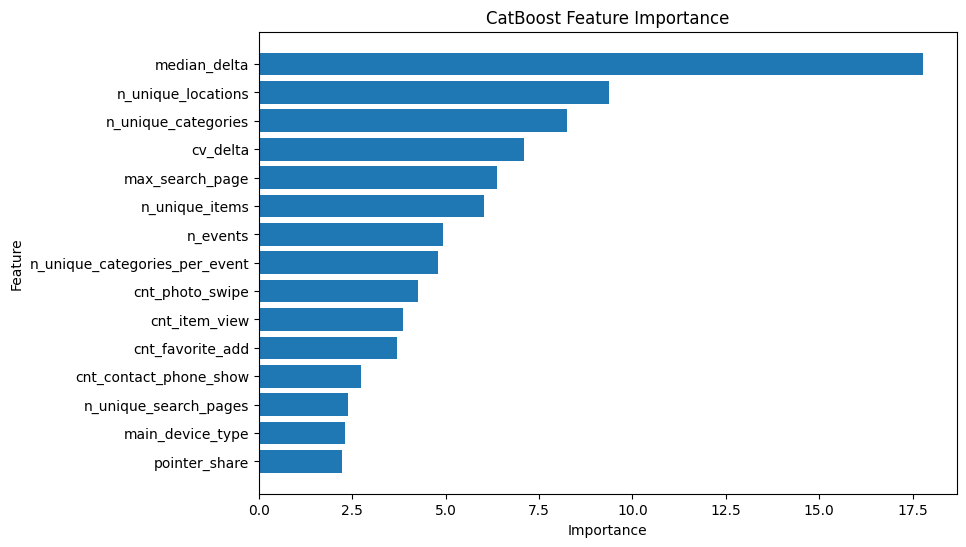

In [66]:
top_n = 15

plt.figure(figsize=(9, 6))

plt.barh(
    feature_importance['feature'].head(top_n)[::-1],
    feature_importance['importance'].head(top_n)[::-1]
)

plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('CatBoost Feature Importance')
plt.show()

Сильнее всего выделяется `median_delta`, что согласуется с EDA: типичный интервал между действиями у ботов и обычных пользователей заметно различается.

Также высоко находятся признаки разнообразия (`n_unique_locations`, `n_unique_categories`, `n_unique_items`) и поведения в поиске (`max_search_page`). Второй временной признак `cv_delta` тоже оказался среди наиболее важных.

При этом низкая важность отдельного признака еще не означает, что вся его группа бесполезна. Поэтому дальше проверим группы признаков с помощью ablation-анализа.

#### 3.2.3 Ablation-анализ
Из смысловых категорий можно выделить следующие:
1. активность
    - `n_events`
2. количества по типу событий
    - `cnt_...`
3. временные
    - `median_delta`
    - `cv_delta`
4. разнообразие
    - `n_unique...`
5. поиск
    - `max_search_page`
    - `n_unique_search_pages`
6. user_agent
    - связанные с `user_agent`
7. platform
8. pointer
    - `pointer_share`

In [67]:
feature_groups = {
    'activity': [
        'n_events'
    ],

    'event_counts': [
        col for col in feature_cols_v1
        if col.startswith('cnt_')
    ],

    'timing': [
        'median_delta',
        'cv_delta'
    ],

    'diversity': [
        'n_unique_items',
        'n_unique_categories',
        'n_unique_locations',
        'n_unique_queries',
        'n_unique_categories_per_event'
    ],

    'search': [
        'max_search_page',
        'n_unique_search_pages'
    ],

    'user_agent': [
        'main_client_type',
        'main_browser_family',
        'main_os_family',
        'main_device_type',
        'has_programmatic_usr_a',
        'programmatic_events'
    ],

    'platform': [
        'main_platform'
    ],

    'pointer': [
        'pointer_share'
    ]
}

In [68]:
def evaluate_catboost(selected_features, model_name):
    X_fit_exp = X_train_v1.loc[
        ~is_valid,
        selected_features
    ].copy()

    X_valid_exp = X_train_v1.loc[
        is_valid,
        selected_features
    ].copy()

    current_cat_features = [
        col for col in cat_features
        if col in selected_features
    ]

    for col in current_cat_features:
        X_fit_exp[col] = (
            X_fit_exp[col]
            .fillna('unknown')
            .astype(str)
        )

        X_valid_exp[col] = (
            X_valid_exp[col]
            .fillna('unknown')
            .astype(str)
        )

    model = CatBoostClassifier(
        iterations=500,
        depth=6,
        learning_rate=0.05,
        loss_function='Logloss',
        random_seed=42,
        verbose=False
    )

    model.fit(
        X_fit_exp,
        y_fit,
        cat_features=current_cat_features
    )

    pred = model.predict_proba(
        X_valid_exp
    )[:, 1]

    return {
        'experiment': model_name,
        'n_features': len(selected_features),
        'P@R0.7': precision_at_recall(y_valid, pred),
        'PR-AUC': average_precision_score(y_valid, pred),
        'ROC-AUC': roc_auc_score(y_valid, pred),
        'Recall@FPR1%': recall_at_fpr(
            y_valid,
            pred,
            fpr=0.01
        )
    }

In [69]:
ablation_results = []

ablation_results.append(
    evaluate_catboost(
        feature_cols_v1,
        'Full Feature Set v1'
    )
)

for group_name, group_features in feature_groups.items():

    selected_features = [
        col for col in feature_cols_v1
        if col not in group_features
    ]

    result = evaluate_catboost(
        selected_features,
        f'without_{group_name}'
    )

    ablation_results.append(result)

ablation_results = pd.DataFrame(ablation_results)

ablation_results

,experiment,n_features,P@R0.7,PR-AUC,ROC-AUC,Recall@FPR1%
0,Full Feature Set v1,27,0.513761,0.696720,0.890888,0.50625
1,without_activity,26,0.493450,0.701173,0.889248,0.53125
2,without_event_counts,18,0.449799,0.650957,0.879645,0.43750
3,without_timing,25,0.315493,0.578723,0.859871,0.38125
4,without_diversity,22,0.394366,0.656992,0.860059,0.46250
5,without_search,25,0.480851,0.683979,0.879994,0.53125
6,without_user_agent,21,0.482759,0.680106,0.885425,0.50625
7,without_platform,26,0.549020,0.698335,0.889437,0.51250
8,without_pointer,26,0.560000,0.699743,0.888146,0.51875


Итак, можно заметить, что блок timing, как было видно и из feature_inportance является наиболее значимым, поэтому именно ему будет уделено наибольшее внимание при построении дополнительных признаков. Также внимания заслуживает блок diversity. Стоит отметить, что небольшое улучшение целевой метрики в эксперименте without_platform пока не стоит переоценивать, так как другие метрики изменились мало.

#### 3.2.4 Feature set v2

К Feature Set v1 добавляются:

- `mean_delta` — средний интервал между соседними событиями
- `std_delta` — стандартное отклонение интервалов между событиями
- `q25_delta` — первый квартиль интервалов между событиями
- `q75_delta` — третий квартиль интервалов между событиями
- `categories_per_item` — отношение количества уникальных категорий к количеству уникальных объявлений

In [70]:
EVENT_NAMES = sorted(events_train['event_name'].dropna().unique())



def build_features_v2(events_part, meta, event_names=EVENT_NAMES):
    ev = events_part.copy()
    ev = ev.sort_values(['cookie_id', 'event_ts'])


    # Общая активность
    features = (
        ev.groupby('cookie_id')
        .size()
        .rename('n_events')
        .to_frame()
    )


    # Количество событий каждого типа
    event_counts = (
        ev.groupby(['cookie_id', 'event_name'])
        .size()
        .unstack(fill_value=0)
        .reindex(columns=event_names, fill_value=0)
        .add_prefix('cnt_')
    )

    features = features.join(event_counts)


    # Временные признаки
    ev['delta_sec'] = (
        ev.groupby('cookie_id')['event_ts']
        .diff()
        .dt.total_seconds()
    )

    time_features = (
        ev.groupby('cookie_id')['delta_sec']
        .agg(
            mean_delta='mean',
            median_delta='median',
            std_delta='std',
            q25_delta=lambda x: x.quantile(0.25),
            q75_delta=lambda x: x.quantile(0.75)
        )
    )

    time_features['cv_delta'] = (
        time_features['std_delta']
        / time_features['mean_delta']
    )

    time_features['cv_delta'] = (
        time_features['cv_delta']
        .replace([np.inf, -np.inf], np.nan)
    )

    features = features.join(
        time_features[
            [
                'mean_delta',
                'median_delta',
                'std_delta',
                'q25_delta',
                'q75_delta',
                'cv_delta'
            ]
        ]
    )


    # Разнообразие контента
    diversity_features = (
        ev.groupby('cookie_id')
        .agg(
            n_unique_items=('item_id', 'nunique'),
            n_unique_categories=('item_category', 'nunique'),
            n_unique_locations=('item_location', 'nunique'),
            n_unique_queries=('search_query', 'nunique')
        )
    )

    features = features.join(diversity_features)

    features['n_unique_categories_per_event'] = (
        features['n_unique_categories']
        / features['n_events']
    )

    features['categories_per_item'] = (
        features['n_unique_categories']
        / features['n_unique_items'].replace(0, np.nan)
    )


    # Поведение в поисковой выдаче
    search_features = (
        ev.groupby('cookie_id')
        .agg(
            max_search_page=('search_page', 'max'),
            n_unique_search_pages=('search_page', 'nunique')
        )
    )

    features = features.join(search_features)


    # User-Agent
    usr_a = ev['user_agent'].str.lower().fillna('')

    programmatic_pattern = (
        r'^(?:python-urllib3|go-http-client|scrapy|'
        r'curl|node-fetch|python-requests)/'
    )

    ev['is_programmatic_usr_a'] = usr_a.str.contains(
        programmatic_pattern,
        regex=True
    )


    # User-Agent/Тип клиента
    ev['client_type'] = np.select(
        [
            ev['is_programmatic_usr_a'],
            usr_a.str.startswith('avito/'),
            usr_a.str.contains('mozilla/')
        ],
        [
            'programmatic',
            'avito_app',
            'browser'
        ],
        default='other'
    )


    # User-Agent/Семейство ОС
    ev['os_family'] = np.select(
        [
            usr_a.str.contains(r'android'),
            usr_a.str.contains(r'iphone|ipad|ipod'),
            usr_a.str.contains(r'windows'),
            usr_a.str.contains(r'macintosh|mac os x'),
            usr_a.str.contains(r'linux')
        ],
        [
            'android',
            'ios',
            'windows',
            'macos',
            'linux'
        ],
        default='other'
    )


    # User-Agent/Семейство браузера
    ev['browser_family'] = np.select(
        [
            usr_a.str.contains(r'edg/|edgios/|edga/'),
            usr_a.str.contains(r'firefox/|fxios/'),
            usr_a.str.contains(r'chrome/|crios/'),
            (
                usr_a.str.contains(r'safari/')
                & ~usr_a.str.contains(
                    r'chrome/|crios/|edg/|edgios/|edga/'
                )
            )
        ],
        [
            'edge',
            'firefox',
            'chrome',
            'safari'
        ],
        default='other'
    )


    # User-Agent/Тип устройства
    ev['device_type'] = np.select(
        [
            usr_a.str.contains(r'ipad'),
            usr_a.str.contains(r'iphone|ipod'),
            (
                usr_a.str.contains(r'android')
                & ~usr_a.str.contains(r'mobile')
            ),
            usr_a.str.contains(r'android.*mobile'),
            (
                usr_a.str.contains(r'windows|macintosh|mac os x|linux')
                & ~usr_a.str.contains(r'android')
            )
        ],
        [
            'tablet',
            'mobile',
            'tablet',
            'mobile',
            'desktop'
        ],
        default='other'
    )


    usr_a_features = (
        ev.groupby('cookie_id')
        .agg(
            main_client_type=('client_type', most_common),
            main_browser_family=('browser_family', most_common),
            main_os_family=('os_family', most_common),
            main_device_type=('device_type', most_common),
            has_programmatic_usr_a=('is_programmatic_usr_a', 'max'),
            programmatic_events=('is_programmatic_usr_a', 'sum')
        )
    )

    usr_a_features['has_programmatic_usr_a'] = (
        usr_a_features['has_programmatic_usr_a'].astype(int)
    )

    features = features.join(usr_a_features)


    # Platform
    ev['platform_norm'] = (
        ev['platform']
        .str.lower()
        .replace({'iphone': 'ios'})
        .fillna('other')
    )

    platform_features = (
        ev.groupby('cookie_id')
        .agg(
            main_platform=('platform_norm', most_common)
        )
    )

    features = features.join(platform_features)


    # Pointer
    ev['has_pointer'] = (
        ev['pointer_x'].notna()
        & ev['pointer_y'].notna()
    )

    pointer_features = (
        ev.groupby('cookie_id')
        .agg(
            pointer_share=('has_pointer', 'mean')
        )
    )

    features = features.join(pointer_features)


    # Возвращаем cookie в порядке исходной meta-таблицы
    features = (
        meta[['cookie_id']]
        .merge(
            features.reset_index(),
            on='cookie_id',
            how='left'
        )
    )

    return features

In [71]:
# Пересобираем список признаков
X_train_v2 = build_features_v2(events_train, train)
X_test_v2 = build_features_v2(events_test, test)


feature_cols_v2 = [
    col for col in X_train_v2.columns
    if col != 'cookie_id'
]

is_valid = train['window_start_ts'].ge('2026-04-17').values

y = train['target'].values

X_fit_v2 = X_train_v2.loc[~is_valid, feature_cols_v2].copy()
X_valid_v2 = X_train_v2.loc[is_valid, feature_cols_v2].copy()

y_fit = y[~is_valid]
y_valid = y[is_valid]

for col in cat_features:
    X_fit_v2[col] = X_fit_v2[col].fillna('unknown').astype(str)
    X_valid_v2[col] = X_valid_v2[col].fillna('unknown').astype(str)

cat_model_v2 = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    loss_function='Logloss',
    random_seed=42,
    verbose=100
)

cat_model_v2.fit(
    X_fit_v2,
    y_fit,
    cat_features=cat_features
)

cat_pred_v2 = cat_model_v2.predict_proba(X_valid_v2)[:, 1]

cat_score_v2 = precision_at_recall(
    y_valid,
    cat_pred_v2
)

print('P@R0.7:', round(cat_score_v2, 4))
print('ROC-AUC:', round(roc_auc_score(y_valid, cat_pred_v2), 4))
print('PR-AUC:', round(average_precision_score(y_valid, cat_pred_v2), 4))
print(
    'Recall @ FPR=1%:',
    round(recall_at_fpr(y_valid, cat_pred_v2, fpr=0.01), 4)
)

0:	learn: 0.6306660	total: 22.2ms	remaining: 11.1s
100:	learn: 0.1393221	total: 2.04s	remaining: 8.04s
200:	learn: 0.1189038	total: 3.99s	remaining: 5.94s
300:	learn: 0.1022427	total: 6.07s	remaining: 4.01s
400:	learn: 0.0878275	total: 9.4s	remaining: 2.32s
499:	learn: 0.0778961	total: 11.4s	remaining: 0us
P@R0.7: 0.549
ROC-AUC: 0.8906
PR-AUC: 0.7051
Recall @ FPR=1%: 0.525


In [72]:
comparison = pd.DataFrame({
    'model': [
        'CatBoost Feature Set v1',
        'CatBoost Feature Set v2'
    ],
    'P@R0.7': [
        cat_score_v1,
        cat_score_v2
    ]
})

comparison['delta'] = (
    comparison['P@R0.7']
    - cat_score_v1
)

comparison

,model,P@R0.7,delta
0,CatBoost Feature Set v1,0.513761,0.000000
1,CatBoost Feature Set v2,0.549020,0.035258


Добавленные признаки улучшили все рассматриваемые метрики. Основная метрика выросла, поэтому дальше в качестве основного набора признаков будем использовать Feature Set v2.

#### 3.2.5 Проверка на нескольких временных разбиениях

In [73]:

def evaluate_time_split(valid_start, valid_end):

    fit_mask = train['window_start_ts'] < pd.Timestamp(valid_start)

    valid_mask = (
        (train['window_start_ts'] >= pd.Timestamp(valid_start))
        & (train['window_start_ts'] < pd.Timestamp(valid_end))
    )

    X_fit_split = X_train_v2.loc[
        fit_mask, feature_cols_v2
    ].copy()

    X_valid_split = X_train_v2.loc[
        valid_mask, feature_cols_v2
    ].copy()

    y_fit_split = train.loc[
        fit_mask, 'target'
    ].values

    y_valid_split = train.loc[
        valid_mask, 'target'
    ].values


    # Категориальные признаки
    for col in cat_features:
        X_fit_split[col] = (
            X_fit_split[col]
            .fillna('unknown')
            .astype(str)
        )

        X_valid_split[col] = (
            X_valid_split[col]
            .fillna('unknown')
            .astype(str)
        )


    model = CatBoostClassifier(
        iterations=500,
        depth=6,
        learning_rate=0.05,
        loss_function='Logloss',
        random_seed=42,
        verbose=False
    )

    model.fit(
        X_fit_split,
        y_fit_split,
        cat_features=cat_features
    )

    pred = model.predict_proba(
        X_valid_split
    )[:, 1]


    return {
        'valid_period': f'{valid_start} — {valid_end}',
        'train_size': len(X_fit_split),
        'valid_size': len(X_valid_split),
        'valid_bots': y_valid_split.sum(),

        'P@R0.7': precision_at_recall(
            y_valid_split,
            pred
        ),

        'PR-AUC': average_precision_score(
            y_valid_split,
            pred
        ),

        'ROC-AUC': roc_auc_score(
            y_valid_split,
            pred
        ),

        'Recall@FPR1%': recall_at_fpr(
            y_valid_split,
            pred,
            fpr=0.01
        )
    }

In [74]:
time_splits = [
    ('2026-04-11', '2026-04-14'),
    ('2026-04-14', '2026-04-17'),
    ('2026-04-17', '2026-04-20')
]

temporal_results = []

for valid_start, valid_end in time_splits:

    result = evaluate_time_split(
        valid_start,
        valid_end
    )

    temporal_results.append(result)


temporal_results = pd.DataFrame(
    temporal_results
)

temporal_results

,valid_period,train_size,valid_size,valid_bots,P@R0.7,PR-AUC,ROC-AUC,Recall@FPR1%
0,2026-04-11 — 2026-04-14,4217,2556,199,0.466667,0.672980,0.878893,0.477387
1,2026-04-14 — 2026-04-17,6773,2367,195,0.513109,0.716080,0.913151,0.538462
2,2026-04-17 — 2026-04-20,9140,1951,160,0.549020,0.705115,0.890560,0.525000


#### 3.2.6 Подбор гиперпараметров с помощью Optuna

In [75]:
!pip install optuna -q

import optuna
from optuna.samplers import TPESampler


cat_features = [
    'main_client_type',
    'main_browser_family',
    'main_os_family',
    'main_device_type',
    'main_platform'
]


is_valid = train['window_start_ts'].ge('2026-04-17').values

y = train['target'].values

X_fit_opt = X_train_v2.loc[
    ~is_valid, feature_cols_v2
].copy()

X_valid_opt = X_train_v2.loc[
    is_valid, feature_cols_v2
].copy()

y_fit_opt = y[~is_valid]
y_valid_opt = y[is_valid]


for col in cat_features:
    X_fit_opt[col] = (
        X_fit_opt[col]
        .fillna('unknown')
        .astype(str)
    )

    X_valid_opt[col] = (
        X_valid_opt[col]
        .fillna('unknown')
        .astype(str)
    )


def objective(trial):

    params = {
        'iterations': trial.suggest_int(
            'iterations',
            300,
            900,
            step=100
        ),

        'depth': trial.suggest_int(
            'depth',
            4,
            8
        ),

        'learning_rate': trial.suggest_float(
            'learning_rate',
            0.02,
            0.12,
            log=True
        ),

        'l2_leaf_reg': trial.suggest_float(
            'l2_leaf_reg',
            1.0,
            20.0,
            log=True
        ),

        'random_strength': trial.suggest_float(
            'random_strength',
            0.0,
            2.0
        ),

        'bagging_temperature': trial.suggest_float(
            'bagging_temperature',
            0.0,
            2.0
        ),

        'loss_function': 'Logloss',
        'random_seed': 42,
        'verbose': False,
        'allow_writing_files': False
    }

    model = CatBoostClassifier(**params)

    model.fit(
        X_fit_opt,
        y_fit_opt,
        cat_features=cat_features
    )

    pred = model.predict_proba(
        X_valid_opt
    )[:, 1]

    score = precision_at_recall(
        y_valid_opt,
        pred
    )

    return score


study = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=42)
)

study.optimize(
    objective,
    n_trials=40,
    show_progress_bar=True
)

print('Best P@R0.7:', round(study.best_value, 4))
print('\nBest params:')

study.best_params

[I 2026-09-28 18:45:24,430] A new study created in memory with name: no-name-a001b971-b6c9-4d58-81cd-f228126b596f


  0%|          | 0/40 [00:00<?, ?it/s]

[I 2026-09-28 18:45:43,996] Trial 0 finished with value: 0.5258215962441315 and parameters: {'iterations': 500, 'depth': 8, 'learning_rate': 0.07423898007815308, 'l2_leaf_reg': 6.009974718380312, 'random_strength': 0.31203728088487304, 'bagging_temperature': 0.3119890406724053}. Best is trial 0 with value: 0.5258215962441315.
[I 2026-09-28 18:45:55,663] Trial 1 finished with value: 0.448 and parameters: {'iterations': 300, 'depth': 8, 'learning_rate': 0.05872031730223161, 'l2_leaf_reg': 8.341106432362084, 'random_strength': 0.041168988591604894, 'bagging_temperature': 1.9398197043239886}. Best is trial 0 with value: 0.5258215962441315.
[I 2026-09-28 18:46:11,302] Trial 2 finished with value: 0.5229357798165137 and parameters: {'iterations': 800, 'depth': 5, 'learning_rate': 0.027702395242115332, 'l2_leaf_reg': 1.7322667470546256, 'random_strength': 0.6084844859190754, 'bagging_temperature': 1.0495128632644757}. Best is trial 0 with value: 0.5258215962441315.
[I 2026-09-28 18:46:22,670]

{'iterations': 700,
 'depth': 6,
 'learning_rate': 0.0497133262770896,
 'l2_leaf_reg': 1.1061828766522233,
 'random_strength': 0.2756269211650312,
 'bagging_temperature': 0.47805610557444933}

In [76]:
best_params = study.best_params.copy()

cat_model_tuned = CatBoostClassifier(
    **best_params,
    loss_function='Logloss',
    random_seed=42,
    verbose=False,
    allow_writing_files=False
)

cat_model_tuned.fit(
    X_fit_opt,
    y_fit_opt,
    cat_features=cat_features
)

cat_pred_tuned = cat_model_tuned.predict_proba(
    X_valid_opt
)[:, 1]

tuned_score = precision_at_recall(
    y_valid_opt,
    cat_pred_tuned
)

print('P@R0.7:', round(tuned_score, 4))
print(
    'PR-AUC:',
    round(
        average_precision_score(
            y_valid_opt,
            cat_pred_tuned
        ),
        4
    )
)
print(
    'ROC-AUC:',
    round(
        roc_auc_score(
            y_valid_opt,
            cat_pred_tuned
        ),
        4
    )
)
print(
    'Recall @ FPR=1%:',
    round(
        recall_at_fpr(
            y_valid_opt,
            cat_pred_tuned,
            fpr=0.01
        ),
        4
    )
)

P@R0.7: 0.6087
PR-AUC: 0.7147
ROC-AUC: 0.8861
Recall @ FPR=1%: 0.5437


In [77]:
pd.DataFrame({
    'model': [
        'CatBoost v1',
        'CatBoost v2',
        'CatBoost v2 + Optuna'
    ],
    'P@R0.7': [
        cat_score_v1,
        cat_score_v2,
        tuned_score
    ]
})

,model,P@R0.7
0,CatBoost v1,0.513761
1,CatBoost v2,0.549020
2,CatBoost v2 + Optuna,0.608696


## 4. Финальная модель

После подбора параметров получено небольшое улучшение основной метрики — до 0.5926.

Для финального предсказания модель обучается уже на всей обучающей выборке с подобранными параметрами. После этого рассчитываются вероятности принадлежности к классу ботов для объектов из test.

In [78]:
X_full = X_train_v2[feature_cols_v2].copy()
X_test_final = X_test_v2[feature_cols_v2].copy()

y_full = train['target'].values


# Подготовка категориальных признаков
for col in cat_features:
    X_full[col] = (
        X_full[col]
        .fillna('unknown')
        .astype(str)
    )

    X_test_final[col] = (
        X_test_final[col]
        .fillna('unknown')
        .astype(str)
    )

In [79]:
final_model = CatBoostClassifier(
    **study.best_params,
    loss_function='Logloss',
    random_seed=42,
    verbose=False,
    allow_writing_files=False
)

final_model.fit(
    X_full,
    y_full,
    cat_features=cat_features
)

CatBoostClassifier(allow_writing_files=False, bagging_temperature=0.47805610557444933, depth=6, iterations=700, l2_leaf_reg=1.1061828766522233, learning_rate=0.0497133262770896, loss_function='Logloss', random_seed=42, random_strength=0.2756269211650312, verbose=False)

In [80]:
test_pred = final_model.predict_proba(
    X_test_final
)[:, 1]

test_pred[:10]

array([0.0008695 , 0.15196914, 0.01664907, 0.00416021, 0.00809556,
       0.01084827, 0.29108035, 0.01995285, 0.00224893, 0.18281604])

### 4.1 Формирование submission

In [81]:
submission = pd.DataFrame({
    'cookie_id': test['cookie_id'],
    'score': test_pred
})

submission.head()

,cookie_id,score
0,ck_315fb710a0e371e7,0.000870
1,ck_a76ee3b3e3e522fd,0.151969
2,ck_94c9a4d382689e82,0.016649
3,ck_8eaf9509ad9462a0,0.004160
4,ck_9a88a5a989cb5bc6,0.008096


In [82]:
print('Размер:', submission.shape)
print('Пропуски:', submission.isna().sum().sum())
print('Уникальных cookie:', submission['cookie_id'].nunique())
print('Минимальный score:', submission['score'].min())
print('Максимальный score:', submission['score'].max())

Размер: (4909, 2)
Пропуски: 0
Уникальных cookie: 4909
Минимальный score: 6.13287317099628e-05
Максимальный score: 0.9998966257253286


In [83]:
submission.to_csv(
    'submission.csv',
    index=False
)